In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
from tqdm import trange
from astropy.cosmology import Planck18
import pyccl as ccl

In [2]:
plt.rcParams['figure.dpi'] = 85
plt.rcParams['figure.figsize'] = [10, 8]
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['lines.linewidth'] = 5
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['axes.linewidth'] = 2.5
plt.rcParams['xtick.major.size'] = 7
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['ytick.major.size'] = 4.32
plt.rcParams['ytick.minor.size'] = 2.46
plt.rcParams['xtick.major.width'] = 1.6
plt.rcParams['xtick.minor.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.6
plt.rcParams['ytick.minor.width'] = 1.2
plt.rcParams['figure.dpi'] = 85

# Load data from local machine

In [3]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [4]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [5]:
G_hi = 20.5

In [6]:
nthreads = 18

In [7]:
mask_type = 'selfunc'

# Visuals

In [8]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
{'NAME': '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog', 'ABBRV': 'Quaia'}
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


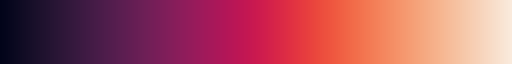

In [9]:
cmap = sns.color_palette("rocket", as_cmap=True)
cmap

In [10]:
zbin_array = [0.0,1.0,2.0,3.0,4.0]

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2133/2690018502.py:18: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('N$_\mathrm{QSO}$')
/tmp/ipykernel_2133/2690018502.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_xlabel('N$_\mathrm{QSO}$')


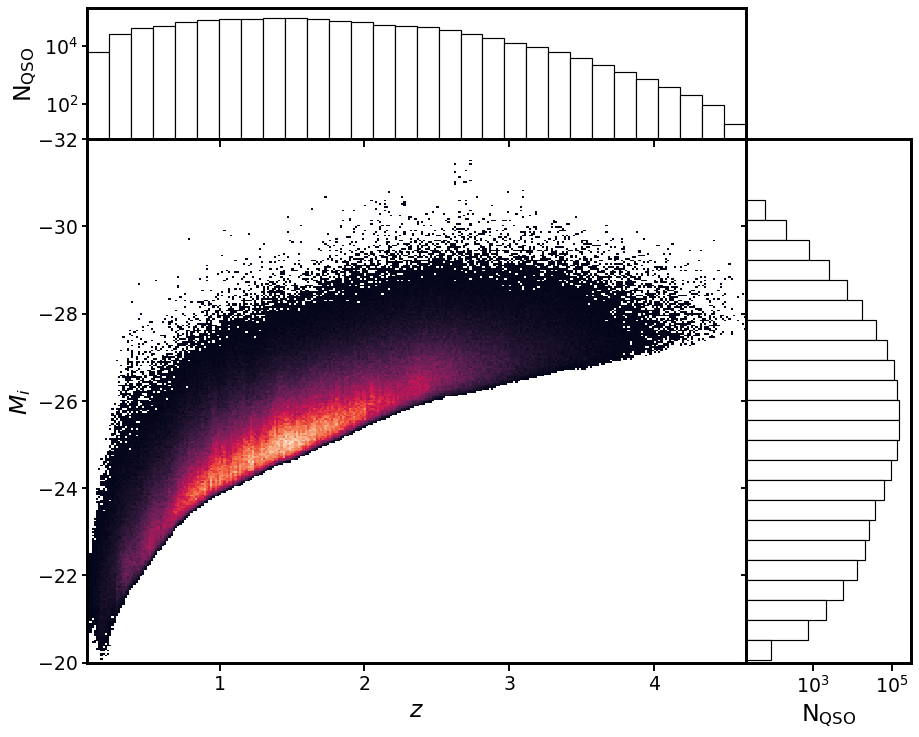

In [11]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = 'black', bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in four z bins
## $w_p(r_p)$

In [12]:
# Create the bins array
offset = 2.5
delta_max = 64
delta_min = np.min((np.floor((30-0.15)/offset), delta_max))

rmin = 30-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 80+delta_max*offset # 200
nbins = 20 + int(delta_min+delta_max) #90 #20
rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins, quaia.recenter(rbins), np.diff(quaia.recenter(rbins))

(array([  2.5,   5. ,   7.5,  10. ,  12.5,  15. ,  17.5,  20. ,  22.5,
         25. ,  27.5,  30. ,  32.5,  35. ,  37.5,  40. ,  42.5,  45. ,
         47.5,  50. ,  52.5,  55. ,  57.5,  60. ,  62.5,  65. ,  67.5,
         70. ,  72.5,  75. ,  77.5,  80. ,  82.5,  85. ,  87.5,  90. ,
         92.5,  95. ,  97.5, 100. , 102.5, 105. , 107.5, 110. , 112.5,
        115. , 117.5, 120. , 122.5, 125. , 127.5, 130. , 132.5, 135. ,
        137.5, 140. , 142.5, 145. , 147.5, 150. , 152.5, 155. , 157.5,
        160. , 162.5, 165. , 167.5, 170. , 172.5, 175. , 177.5, 180. ,
        182.5, 185. , 187.5, 190. , 192.5, 195. , 197.5, 200. , 202.5,
        205. , 207.5, 210. , 212.5, 215. , 217.5, 220. , 222.5, 225. ,
        227.5, 230. , 232.5, 235. , 237.5, 240. ]),
 array([  3.75,   6.25,   8.75,  11.25,  13.75,  16.25,  18.75,  21.25,
         23.75,  26.25,  28.75,  31.25,  33.75,  36.25,  38.75,  41.25,
         43.75,  46.25,  48.75,  51.25,  53.75,  56.25,  58.75,  61.25,
         63.75,  66.25

In [22]:
pimax = 80 # 40 # 5000.0 # 40.0

In [13]:
zbin_array = [0.0,1.0,2.0,3.0,4.0]

In [14]:
h = 0.674
Omega_m_planck20 = 0.315

In [15]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [16]:
Om0 = {'Planck': cosmo_planck18['Omega_m'], 'Quaia': 0.343}

## Pick cosmology

In [17]:
cosmo = 'Planck' #'Planck'

In [18]:
L_bol = [44.5, 45.0, 45.5, 46.0, 46.5]

In [19]:
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(L_bol)))

<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2133/358495681.py:30: SyntaxWarning: invalid escape sequence '\m'
  ax1.hist(tab_datahi_mask_zbin0['L_bol'], label = '$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[i]),
/tmp/ipykernel_2133/358495681.py:38: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('$L_\mathrm{bol}$ [erg $\mathrm{s}^{-1}]$')
/tmp/ipykernel_2133/358495681.py:39: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$N_\mathrm{QSO}$')


G20.5_zmin0.0zmax1.0_Lbolmin44.5: 0.30              225780 vs 324311


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin0.0zmax1.0_Lbolmin45.0: 0.30              214489 vs 308126


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


...

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin0.0zmax1.0_Lbolmin46.0: 0.30              17294 vs 24716


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin0.0zmax1.0_Lbolmin46.5: 0.32              1549 vs 2271


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


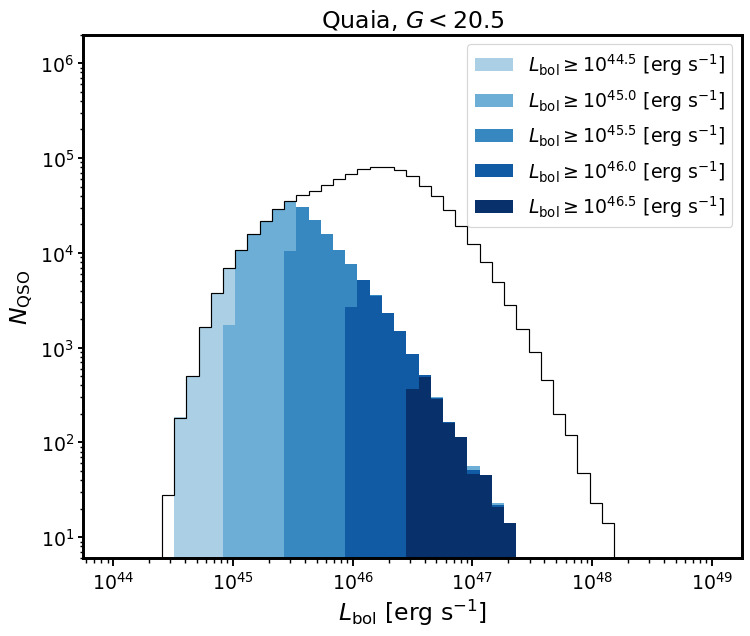

In [23]:
# plot data
bins = np.logspace(44, 49)
wp, rpavg = [], []
fac_rand = 25
mask = 0.5
fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_hi)
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

fn_datahi = '../data/quaia_G{}.fits'.format(G_hi)
tab_datahi = Table.read(fn_datahi)
pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
mask_datahi = selfunc_hi[pixel_indices_datahi]>=np.percentile(selfunc_hi, mask*100)

# plot!
fig = plt.figure(figsize = (10, 8))
gs = gridspec.GridSpec(1, 1, wspace = 0)

ax1 = fig.add_subplot(gs[0])
quaia.L_bol(tab_datahi)
ax1.hist(tab_datahi['L_bol'][mask_datahi], bins=bins, histtype = 'step', color='black')

for i in range(len(L_bol)):
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _ = quaia.make_bins(G_hi, [0, i], True, ['z', 'L_bol'], 
                                                                                         bins = [zbin_array, L_bol], tab_gcat_type = 'data', 
                                                                                          method = ['minmax', 'threshold'], fac_rand = fac_rand, 
                                                                                          mask = mask*100, percentile = True, n_bins = [None, None])

    quaia.L_bol(tab_datahi_mask_zbin0)
    ax1.hist(tab_datahi_mask_zbin0['L_bol'], label = '$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[i]), 
             bins = bins, color = cmap_blue[i])

    wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, Om0 = Om0[cosmo], 
                                                      h = Planck18.h, rbins = rbins, nbins = nbins, pimax = pimax)
    wp.append(wp_datahi_zbin0)
    rpavg.append(rpavg_datahi_zbin0)

ax1.set_xlabel('$L_\mathrm{bol}$ [erg $\mathrm{s}^{-1}]$')
ax1.set_ylabel('$N_\mathrm{QSO}$')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylim(6,2e6)
ax1.set_title('Quaia, $G<{}$'.format(G_hi))
ax1.legend()

plt.show()

# Use delete-one jackknife resampling
## Split the sky into RA stripes

In [21]:
N = 25 #10
ra_bins = np.linspace(0, 360, N+1)
for i in range(N): #-1):
    
    delete = (tab_datahi_mask_zbin0['ra']>=ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] <ra_bins[i])
    print(np.unique(np.digitize(tab_datahi_mask_zbin0['ra'][delete], ra_bins)))

[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 11 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 11 12 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 11 12 1

## Compute $w_p(r_p)$ in each jackknife bin

In [25]:
wp_jackknife, rpavg_jackknife = {L: [] for L in L_bol}, {L: [] for L in L_bol}

for j in range(len(L_bol)):
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _ = quaia.make_bins(G_hi, [0, j], True, ['z', 'L_bol'], 
                                                                                         bins = [zbin_array, L_bol], tab_gcat_type = 'data', 
                                                                                          method = ['minmax', 'threshold'], fac_rand = fac_rand, 
                                                                                          mask = mask*100, percentile = True, n_bins = [None, None])

    for i in trange(N):
    
        jackknife_data = (tab_datahi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] < ra_bins[i])
        jackknife_rand = (tab_randhi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_randhi_mask_zbin0['ra'] < ra_bins[i])

        wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0[jackknife_data], tab_randhi_mask_zbin0[jackknife_rand], key_zbin0, Om0 = Om0[cosmo], 
                                                      h = Planck18.h, nthreads = nthreads, rbins = rbins, nbins = nbins, pimax = pimax)
        wp_jackknife[L_bol[i]].append(wp_datahi_zbin0)
        rpavg_jackknife[L_bol[i]].append(rpavg_datahi_zbin0)

G20.5_zmin0.0zmax1.0_Lbolmin44.5: 0.30              225780 vs 324311


  0%|          | 0/25 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
 20%|██        | 5/25 [07:45<31:01, 93.06s/it]


IndexError: list index out of range

## Compute the jackknife covariance matrix
### \begin{array}{r}
C_{i j}=\frac{N-1}{N} \sum_{k=1}^N\left[w_p^{(k)}\left(r_{p,i}\right)-\bar{w_p}\left(r_{p,i}\right)\right] \\
{\left[w_p^{(k)}\left(r_{p,j}\right)-\bar{w_p}\left(r_{p,j}\right)\right]}
\end{array}

In [ ]:
C = {L: [] for L in L_bol}
for L in L_bol:
    
    wp_mean = np.nanmean(wp_jackknife[L], axis = 0)  # is it ok to ignore nan values?
    delta = wp_jackknife[L]-wp_mean
    C[L] = (N-1)/N*(delta.T @ delta)

## Save the full covariance matrix

In [ ]:
for L in L_bol:
    
    np.save('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z0.0_Lbolmin{}_N{}_{}'.format(G_hi, rmin, rmax, nbins, pimax, L, N, cosmo), C[L])

# Plot

In [ ]:
# plot!
r = quaia.recenter(rbins)
for i in range(len(L_bol)):
    
    sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z0.0_Lbolmin{}_N{}_{}'.format(G_hi, rmin, rmax, nbins, pimax, L, N, cosmo))))
    plt.errorbar(rpavg[i], wp[i], marker = 'o', label = '$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[i]),
             linewidth = 2.5, color = cmap_blue[i], yerr = sigma) # np.sqrt(np.diag(C[zbin])))
    plt.xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        plt.xscale('log')
    plt.yscale('log')
    plt.xlim(r[0], r[-1])
    plt.legend()
    plt.ylabel(r"$w_p(r_p) [h^{-1}$ Mpc]")
plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (20,9)) 
grid = gridspec.GridSpec(2, 6, hspace = 0.4) 

ax1 = plt.subplot(grid[0, 0:2])
ax2 = plt.subplot(grid[0, 2:4])
ax3 = plt.subplot(grid[0, 4:6])
ax4 = plt.subplot(grid[1, 1:3])
ax5 = plt.subplot(grid[1, 3:5])
axlist = [ax1, ax2, ax3, ax4, ax5] #https://www.geeksforgeeks.org/matplotlib-gridspec-gridspec-class-in-python/

for i in range(len(L_bol)):
    
    ax1 = axlist[i]
    
    sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z0.0_Lbolmin{}_N{}_{}'.format(G_hi, rmin, rmax, nbins, pimax, L, N, cosmo))))
    ax1.errorbar(r, cf[i], marker = 'o', label = '$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[i]), 
             linewidth = 2.5, color = cmap_blue[i], yerr = sigma, linestyle = 'None')
    ax1.errorbar(rpavg[i], wp[i], marker = 'o', label = '$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[i]), color = cmap_blue[i],
             linewidth = 2.5, yerr = sigma, linestyle = 'None')    
    ax1.set_title('$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[i]))
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(r[0], r[-1])
    ax1.set_ylim(4e-2, 3e1)
    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if (i==0) or (i==3):
        ax1.set_ylabel(r"$w_p(r_p) [h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])

plt.show()

## Plot correlation matrix

In [ ]:
cmap = sns.color_palette("vlag", as_cmap=True)

# plot!
fig = plt.figure(figsize = (20,9)) 
grid = gridspec.GridSpec(2, 6, hspace = 0.4) 

ax1 = plt.subplot(grid[0, 0:2])
ax2 = plt.subplot(grid[0, 2:4])
ax3 = plt.subplot(grid[0, 4:6])
ax4 = plt.subplot(grid[1, 1:3])
ax5 = plt.subplot(grid[1, 3:5])
axlist = [ax1, ax2, ax3, ax4, ax5] #https://www.geeksforgeeks.org/matplotlib-gridspec-gridspec-class-in-python/

for i in range(len(L_bol)):
    
    ax1 = axlist[i]
    
    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z0.0_Lbolmin{}_N{}_{}'.format(G_hi, rmin, rmax, nbins, pimax, L, N, cosmo))
    matrix = np.corrcoef(C)
    image = ax1.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
    print(image.get_clim())
    ax1.set_xlabel('$r_p (h^{-1}$ Mpc)')
    if (i==0) or (i==3):
        ax1.set_ylabel('$r_p (h^{-1}$ Mpc)')
    else:
        ax1.set_yticks([])
    ax1.set_title('$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[i]))
    
fig.colorbar(image, ax = axlist)
plt.show()